In [1]:
import torch 
from torch.utils.data import Dataset 

import numpy as np

import sys, os
from gmm import GMM
from rockets import RocketDynamics

import matplotlib 
%matplotlib inline 

import matplotlib.pyplot as plt

## Problem Statement and Numerical Setting

Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $\omega$, and let $(0,T]\subset\mathbb{R}$ be the time domain with variable $t$.
We consider the three-dimensional HJ equation with homogeneous Dirichlet boundary conditions,
$$
\begin{align*}
    &\partial \bm{v}_t(t; \bm{x}) + \min\{0, \bm{H}\left(x, \partial \bm{v}_{\bm{x}}(t; \bm{x})\right)\} = 0, \qquad &\bm{v}(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%\bm{v}(0; \bm{x}) &= \bm{g}(0; \bm{x}) \\
%
&\approx \partial \bm{v}^\delta_t(t; \bm{x}) + \min\{0, 
\bm{H}^\delta\left(t; x, \partial \bm{v}^\delta_{\bm{x}}\right)\} = 0, \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
%
&:= \partial \bm{v}^\delta_t(t; \bm{x}) + \min\bigg\{0, 
\max_{\bm{u} \in \mathcal{U}} \min_{\bm{w} \in \mathcal{W}} \, \bigg\langle f(t; \bm{x}, \bm{u}, \bm{w}), \frac{1}{t}(\bm{x} - \text{prox}_{t\bm{g}}(\bm{x})) \bigg\rangle
\bigg\} = 0 \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}).
\end{align*}
$$

This is a model for a one-dimensional rod that conducts heat: the temperature at the ends of the rod are fixed at $0$ and heat is allowed to flow out of the rod through the ends.

In [2]:

class RocketDynamics():
    def __init__(self, u_bound=1, w_bound=1, T=1, L=64, a=32, g=32, resolution=100, rank='cpu'):    
        """
            Rockets Dynamics in relative coordinates.
            The equations of motion are adopted from Dreyfus' construction as follows:
                    &\dot{x} = a(cos(u_p)+ cos(u_e)),\\
                    &\dot{z} = a(sin(u_p)+sin(u_e))-2g,\\
                    &\dot{θ} = u_p - u_e
            
            Let $\Omega = [0,L]\subset \mathbb{R}$ be the spatial domain indicated by the variable $\omega$, and let $(0,T]\subset\mathbb{R}$ be the time domain with variable $t$.
            We consider the three-dimensional HJ equation with homogeneous Dirichlet boundary conditions,
            $$
            \begin{align*}
                &\partial \bm{v}_t(t; \bm{x}) + \min\{0, \bm{H}\left(x, \partial \bm{v}_{\bm{x}}(t; \bm{x})\right)\} = 0, \qquad &\bm{v}(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
            %\bm{v}(0; \bm{x}) &= \bm{g}(0; \bm{x}) \\
            %
            &\approx \partial \bm{v}^\delta_t(t; \bm{x}) + \min\{0, 
            \bm{H}^\delta\left(t; x, \partial \bm{v}^\delta_{\bm{x}}\right)\} = 0, \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}) \nonumber \\
            %
            &:= \partial \bm{v}^\delta_t(t; \bm{x}) + \min\bigg\{0, 
            \max_{\bm{u} \in \mathcal{U}} \min_{\bm{w} \in \mathcal{W}} \, \bigg\langle f(t; \bm{x}, \bm{u}, \bm{w}), \frac{1}{t}(\bm{x} - \text{prox}_{t\bm{g}}(\bm{x})) \bigg\rangle
            \bigg\} = 0 \qquad &\bm{v}^\delta(0; \bm{x}) = \bm{g}(0; \bm{x}).
            \end{align*}
            $$

            Parameters
            ==========
               [x] u_bound: absolute value of the linear speed of the vehicle.
               [x] w_bound: absolute value of the angular speed of the vehicle.
               [x] T:  Temporal domain length (final simulation time).
               [x] L: Spatial domain resolution.
               [x] a: acceleration in ft/sec^2.
               [x] g: gravitational acceleration in ft/sec^2.
               [x] resolution: spattial domain resolution.
               [x] rank: on what GPU(s) to try this algo.
        
        """    
        self.T = T                      # Temporal domain length (final simulation time).
        k = T*10**3 + 1                 # Temporal grid size.
        eps = sys.float_info.epsilon
        self.small   = 100*eps
        self.device  = rank

        self.t_range = torch.linspace(0, T, k)
        self.t_now   = self.t_range[0]
        self.t_steps = self.t_range[1] -  self.t_range[0]

        # inputs 
        self.u = u_bound
        self.w = w_bound
        self.a = a; self.g = g 

        # generate the spatial domain whereupon v(t;x) is domiciled
        self.state_space = self.get_state_space(L, resolution)
        self.state_domain = self.get_state_domain()
        self.initial_conditions = self.get_initial_conditions(L)
        self.values = self.get_values(self.state_space)

        self.state_dim = self.state_space[0].shape[0]

        self.gmm = GMM(device=rank)
        self.gmm_denom = GMM(device=rank)

    def get_state_space(self, L, D):  
        '''
            given a spatial domain length, L and a resolution, 
            compute the spatial components x, z, θ.

            Returns D x N tensor where N is the dimension of the state space, here 3.
        '''      
        # State components, $(x, z, \θ)$
        state_x = torch.linspace(-L, +L, D).to(self.device)  # x spatial grid.
        state_z = torch.linspace(-L, +L, D).to(self.device)  # z spatial grid.
        state_orient = torch.linspace(-torch.pi/2, +torch.pi/2, D).to(self.device)  # x spatial grid.
        # X_all, Z_all, θ_all = torch.meshgrid(*(state_x, state_z, state_orient), indexing='ij') 
        
        state = torch.stack([state_x, state_z, state_orient], dim=1)

        return state 
    
    def get_state_domain(self):
        'interior of the spatial grids ==> Domain of the problem '

        return self.state_space[1:-1, :]

    def get_initial_conditions(self, L):
        
        return self.state_domain
    
    def get_values(self, states):
        """
           The value is the l\_2 distance for every point 
           to the boundary of the target region along the x-z plane.

           Parameters
           ==========
           states: x, z, θ over the whole statge space 
        """
        if isinstance(states, list) or isinstance(states, tuple):
            X, _, θ = states
        else:
            X, _, θ = states[:, 0], 0, states[:, 2]

        values = torch.sqrt(self.a * torch.cos(θ)**2  + (self.a * torch.sin(θ) + \
                                     self.a + self.u * X - self.g)**2)

        return values 

    def get_value(self, state):
        """
           [x] The value is the l\_2 distance to the boundary of the target region in the x-z plane.

           Parameters
           ==========
           states: x, z, θ over the whole statge space 
           a, g, u: see opening doc in class def.
        """
        X, _, θ = state[0], 0, state[2]

        value = torch.sqrt(self.a * torch.cos(θ)**2  + (self.a * torch.sin(θ) + \
                                     self.a + self.u * X - self.g)**2)

        return value
    
    def sample_states(self, num_samples_per_dim=10):
        """ 
            Sample from the state space, compute the values that correspond to these samples,
            and then return the sampled states and values.

            Parameters
            ==========
            - [x] num_samples_per_dim: number of samples per dimension of each state component of the problem.
        """

        X, Z, θ = self.state_space[:,0], self.state_space[:,1], self.state_space[:,2]
        
        num_samples_all_dims = num_samples_per_dim 
        
        assert num_samples_all_dims <= self.state_space.shape[0]-1, "samples along all dims cannot be equal to or greater than the dim of each state component"

        X_flat = X.reshape(-1)
        # X_flat, Z_flat, θ_flat = X.reshape(-1), Z.reshape(-1), θ.reshape(-1)

        probs = torch.ones_like(X_flat, dtype=torch.float) / X_flat.numel()
        
        idx = probs.multinomial(num_samples_all_dims, replacement=True); 

        x_samp = X.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 
        z_samp = Z.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 
        θ_samp = θ.reshape(-1)[idx].reshape(num_samples_per_dim) #, num_samples_per_dim, num_samples_per_dim) 

        return torch.stack([x_samp, z_samp, θ_samp], axis=1)

    def get_prox_innards(self, t, num_samples_per_dim=10, delta=1e-1, alpha=1.0):
        """ 
            Evaluate the innards of the proximal operator 
            of the value function.
            See equation (15) in the paper.

            $$
            Prox_{tg}(x) &= \mathbb{E}_{y\sim\mathcal{N}(x, \delta t)}[\bm{y} \cdot \exp(-\bm{g}(\bm{y})/\delta)]
                            -------------------------------------------------------------------------------------
                                {\mathbb{E}_{y\sim\mathcal{N}(x, \delta t)}[\exp(-\delta^{-1} \, \bm{g}(\bm{y}))]}
            $$

            Arguments
            =========
                [x] - t (tensor): Time > 0
                [x] - num_samples_per_dim: samples drawn per dimension of the state space at time $t$;
                [x] - delta (float, optional):: coefficient of the variance, \delta t to mitigate against overflow.                           
        """
        
        'precompute delta inverse'
        delta_inv = 1/delta 

        # get random sample points on the state space
        state_samples = self.sample_states(num_samples_per_dim)
        state_samples = torch.stack(state_samples, dim=1)
        # print(f'state_samples:  {state_samples.shape}')

        'get the terminal value corresponding to these sample points'
        g_of_y = self.get_values(state_samples)
        
        'denominator of rhs of Proximal expression -- the value within the expectation'
        denom_expect = torch.exp(-delta_inv * g_of_y)

        'numerator of rhs of Proximal expression -- the value within the expectation across all three dims'
        # num_expect = [stata * denom_expect for stata in state_samples]
        # print(f'state_samples: {state_samples.shape} | denom_expect: {denom_expect.shape}')
        num_expect = torch.matmul(state_samples.T, denom_expect.unsqueeze(1))
        # print(f'num_expect: {[x.shape for x in num_expect]} | denom_expect: {denom_expect.shape}')
        # print(f'num_expect: {num_expect.shape} | denom_expect: {denom_expect.shape}')

        return num_expect, denom_expect       


In [3]:
dynamics = RocketDynamics(1, 1, T=1, L=100, a=1, g=32, resolution=1000)

# values = signed distance to target
XZθ = dynamics.state_space
values = dynamics.values

num_samples_per_dim = 20
XZθ_sample = dynamics.sample_states(num_samples_per_dim=num_samples_per_dim)

print(XZθ.shape, values.shape)
# # dynamics.get_prox_innards(t=0, num_samples_per_dim=10, delta=1e-1, alpha=1.0)
# dynamics.compute_proximal(t=0, num_samples_per_dim=10, delta=1e-1, alpha=1.0)


torch.Size([1000, 3]) torch.Size([1000])


In [4]:
class HJ_MAD:
    ''' 
        Hamilton-Jacobi Moreau Adaptive Descent (HJ_MAD) is used to solve nonconvex minimization
        problems via a zeroth-order sampling scheme.
        
        Inputs:
          1)  g           = function to be minimized. Inputs have size (n_samples x n_features). Outputs have size n_samples
          2)  x_true       = true global minimizer
          3)  delta        = coefficient of viscous term in the HJ equation
          4)  int_samples  = number of samples used to approximate expectation in heat equation solution
          6)  t_vec        = time vector containig [initial time, minimum time allowed, maximum time]
          7)  max_iters    = max number of iterations
          8)  tol          = stopping tolerance
          9)  psi          = parameter used to update tk
          10) beta         = exponential averaging term for gradient beta (beta multiplies history, 1-beta multiplies current grad)
          11) eta_vec      = vector containing [eta_minus, eta_plus], where eta_minus < 1 and eta_plus > 1 (part of time update)
          11) alpha        = step size. has to be in between (1-sqrt(eta_minus), 1+sqrt(eta_plus))
          12) fixed_time   = boolean for using adaptive time
          13) verbose      = boolean for printing

        Outputs:
          1) x_opt                    = optimal x_value approximation
          2) xk_hist                  = update history
          3) tk_hist                  = time history
          4) fk_hist                  = function value history
          6) rel_grad_uk_norm_hist    = relative grad norm history of Moreau envelope
    '''
    def __init__(self, g, x_true, delta=0.1, int_samples=100, t_vec = [1.0, 1e-3, 1e1], max_iters=5e4, 
                 tol=5e-2, psi=0.9, beta=[0.9], eta_vec = [0.9, 1.1], alpha=1.0, fixed_time=False, verbose=True):
      
      self.delta            = delta
      self.g                = g
      self.int_samples      = int_samples
      self.max_iters        = max_iters
      self.tol              = tol
      self.t_vec            = t_vec
      self.psi              = psi
      self.x_true           = x_true
      self.beta             = beta 
      self.alpha            = alpha 
      self.eta_vec          = eta_vec
      self.fixed_time       = fixed_time
      self.verbose          = verbose
      
      self.dim = 3; 
      # check that alpha is in right interval
      assert(alpha >= 1-np.sqrt(eta_vec[0]))
      assert(alpha <= 1+np.sqrt(eta_vec[1]))
    
    def compute_grad_uk(self, x, t, g, delta, eps=1e-12):
      ''' 
          Compute the gradient og the Moreau envelope.
      '''

      standard_dev = np.sqrt(delta*t)

      n_features = x.shape[0]
      y = standard_dev * torch.randn(self.int_samples, n_features) + x.view(1, -1)
      
      exp_term = torch.exp(-g(y)/delta)
      phi_delta       = torch.mean(exp_term)

      # separate grad_v into two terms for numerical stability
      numerator = y*exp_term 
      numerator = torch.mean(numerator, dim=0)
      grad_uk = (x.squeeze() -  numerator/(phi_delta + eps)).view(-1, 1) # the t gets canceled with the update formula

      uk       = -delta * torch.log(phi_delta+eps)

      return grad_uk, uk

    def update_time(self, tk, rel_grad_uk_norm):
      '''
        time step rule

        if ‖gk_plus‖≤ psi (‖gk‖+ eps):
          min (eta_plus t,T)
        else
          max (eta_minus t,t_min) otherwise

        OR:
        
        if rel grad norm too small, increase tk (with maximum T).
        else if rel grad norm is too "big", decrease tk with minimum (t_min)
      '''

      eta_minus = self.eta_vec[0]
      eta_plus = self.eta_vec[1]
      T = self.t_vec[2]
      t_min = self.t_vec[1]

      if rel_grad_uk_norm <= self.psi:
        # increase t when relative gradient norm is smaller than psi
        tk = min(eta_plus*tk , T) 
      else:
        # decrease otherwise t when relative gradient norm is smaller than psi
        tk = max(eta_minus*tk, t_min)

      return tk

    def run(self, x0):

      n_features            = x0.shape[0]
      xk_hist               = torch.zeros(int(self.max_iters), n_features)
      xk_error_hist         = torch.zeros(self.max_iters)
      rel_grad_uk_norm_hist = torch.zeros(self.max_iters)
      gk_hist               = torch.zeros(self.max_iters)
      tk_hist               = torch.zeros(self.max_iters)
      counter               = 1

      xk    = x0
      x_opt = xk
      tk    = self.t_vec[0]
      t_max = self.t_vec[2]

      first_moment, _       = self.compute_grad_uk(xk, tk, self.g, self.delta)
      rel_grad_uk_norm      = 1.0

      fmt = '[{:3d}]: gk = {:6.2e} | xk_err = {:6.2e} '
      fmt += ' | |grad_uk| = {:6.2e} | tk = {:6.2e}'

      print('-------------------------- RUNNING HJ-MAD ---------------------------')
      print('dimension = ', self.dim, 'n_samples = ', self.int_samples)

      for k in range(self.max_iters):

        xk_hist[k,:]    = xk.squeeze()

        rel_grad_uk_norm_hist[k]  = rel_grad_uk_norm

        xk_error_hist[k] = torch.norm((xk - self.x_true.squeeze()))
        tk_hist[k]       = tk

        gk_hist[k]       = self.g(xk.squeeze())

        if self.verbose:
          print(fmt.format(k+1, gk_hist[k], xk_error_hist[k], rel_grad_uk_norm_hist[k], tk))

        if xk_error_hist[k] < self.tol:
          tk_hist = tk_hist[0:k+1]
          xk_hist = xk_hist[0:k+1,:]
          xk_error_hist = xk_error_hist[0:k+1]
          rel_grad_uk_norm_hist = rel_grad_uk_norm_hist[0:k+1]
          gk_hist               = gk_hist[0:k+1]
          print('HJ-MAD converged with rel grad norm {:6.2e}'.format(rel_grad_uk_norm_hist[k]))
          print('iter = ', k, ', number of function evaluations = ', len(xk_error_hist)*self.int_samples)
          break
        elif k==self.max_iters-1:
          print('HJ-MAD failed to converge with rel grad norm {:6.2e}'.format(rel_grad_uk_norm_hist[k]))
          print('iter = ', k, ', number of function evaluations = ', len(xk_error_hist)*self.int_samples)
          print('Used fixed time = ', self.fixed_time)

        if k>0:
          if gk_hist[k] < gk_hist[k-1]:
            x_opt = xk 

        xk = xk - self.alpha * first_moment # tk gets canceled out with gradient formula

        if self.fixed_time == False:
          tk = self.update_time(tk, rel_grad_uk_norm)
        
        grad_uk, _ = self.compute_grad_uk(xk, tk, self.g, self.delta)

        grad_uk_norm_old = torch.norm(first_moment)
        first_moment  = self.beta*first_moment + (1-self.beta)*grad_uk

        grad_uk_norm = torch.norm(first_moment)
        rel_grad_uk_norm = grad_uk_norm/(grad_uk_norm_old + 1e-12)

      return x_opt, xk_hist, xk_error_hist, tk_hist, rel_grad_uk_norm_hist, gk_hist

In [ ]:
x_true = torch.zeros([3,1])

int_samples     = 100
max_iters       = int(5e4)

hj_mad_algo = HJ_MAD(dynamics.get_value, x_true, delta=0.1, int_samples=int_samples, t_vec = [1.0, 1e-3, 1e1], max_iters=int(5e4), 
                tol=5e-2, psi=0.9, beta=0.9, eta_vec = [0.9, 1.1], alpha=1.0, fixed_time=False, verbose=True)

# run 30 times 
avg_trials      = 30
avg_func_evals  = 0

torch.manual_seed(123)
np.random.seed(123)

idx = np.random.choice(np.arange(dynamics.state_space.shape[0]), 1).item()
x0 = dynamics.state_space[idx].view(-1, 1)  


for i in range(avg_trials):
  x_opt_MAD, xk_hist_MAD, tk_hist_MAD, xk_error_hist_MAD, \
    rel_grad_uk_norm_hist_MAD, globalk_hist_MAD = hj_mad_algo.run(x0)
  avg_func_evals = avg_func_evals + len(xk_error_hist_MAD)*int_samples

avg_func_evals = avg_func_evals/avg_trials

print('\n\n avg_func_evals = ', avg_func_evals)

-------------------------- RUNNING HJ-MAD ---------------------------
dimension =  3 n_samples =  100
[  1]: gk = 2.89e+01 | xk_err = 5.15e+00  | |grad_uk| = 1.00e+00 | tk = 1.00e+00
[  2]: gk = 3.10e+01 | xk_err = 0.00e+00  | |grad_uk| = 9.00e-01 | tk = 9.00e-01
HJ-MAD converged with rel grad norm 9.00e-01
iter =  1 , number of function evaluations =  200
-------------------------- RUNNING HJ-MAD ---------------------------
dimension =  3 n_samples =  100
[  1]: gk = 2.89e+01 | xk_err = 5.15e+00  | |grad_uk| = 1.00e+00 | tk = 1.00e+00
[  2]: gk = 3.10e+01 | xk_err = 0.00e+00  | |grad_uk| = 9.00e-01 | tk = 9.00e-01
HJ-MAD converged with rel grad norm 9.00e-01
iter =  1 , number of function evaluations =  200
-------------------------- RUNNING HJ-MAD ---------------------------
dimension =  3 n_samples =  100
[  1]: gk = 2.89e+01 | xk_err = 5.15e+00  | |grad_uk| = 1.00e+00 | tk = 1.00e+00
[  2]: gk = 3.10e+01 | xk_err = 0.00e+00  | |grad_uk| = 9.00e-01 | tk = 9.00e-01
HJ-MAD converged w

In [75]:
xk_hist_MAD

tensor([[2.1021, 2.1021, 0.0330],
        [0.0000, 0.0000, 0.0000]])

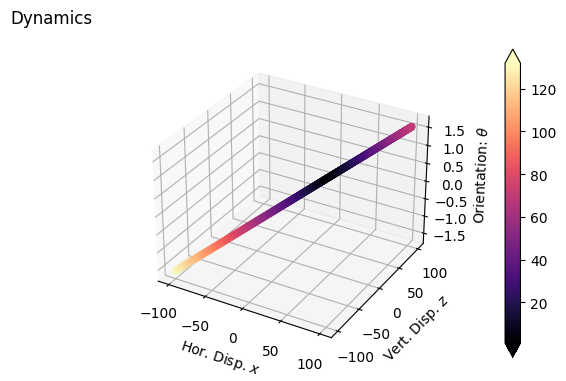

In [5]:
# plot solution space in space time 
fig = plt.figure(figsize=(16,4), )
ax = fig.add_subplot(111, projection='3d')

# Plot a few snapshots.
color = iter(plt.cm.viridis(np.linspace(.25, 1, 5)))
XZT = dynamics.state_space

X_all, Z_all, Theta_all = XZT[:, 0], XZT[:, 1], XZT[:, 2]
cdata = ax.scatter(X_all, Z_all, Theta_all, c=values, cmap="magma") #, shading="nearest", 
plt.colorbar(cdata, ax=ax, extend="both")
ax.set_xlabel(r"Hor. Disp. $x$")
ax.set_ylabel(r"Vert. Disp. $z$")
ax.set_zlabel(r"Orientation: $\theta$")

fig.suptitle("Dynamics")
plt.show()